# **1. Instalação de dependências adicionais**

In [1]:
!pip install pycocotools opencv-python matplotlib

import torch
import torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import os

# Verificar se a GPU foi ativada corretamente
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Ambiente configurado. Dispositivo a ser utilizado: {device}")

Ambiente configurado. Dispositivo a ser utilizado: cuda


# 2. **Dicionário** com os hiperparâmetros ajustados para parear com o YOLOv8

In [2]:
CONFIGURACAO_TREINO = {
    'batch_size': 16,
    'learning_rate': 0.005,      # Mantido o padrão sugerido
    'num_epochs': 60,
    'momentum': 0.9,             # Mantido o padrão do SGD
    'weight_decay': 0.0005,      # Decaimento de peso
    'optimizer': 'SGD'           # Otimizador padrão para o MobileNet
}

print("Parâmetros iniciais definidos:")
for chave, valor in CONFIGURACAO_TREINO.items():
    print(f"{chave}: {valor}")

Parâmetros iniciais definidos:
batch_size: 16
learning_rate: 0.005
num_epochs: 60
momentum: 0.9
weight_decay: 0.0005
optimizer: SGD


# 3. **Verificação** dos Caminhos dos Datasets

In [3]:
import os

caminho_dataset_macas = '/content/drive/MyDrive/Datasets/Macas'
caminho_dataset_garrafas = '/content/drive/MyDrive/Datasets/Garrafas'

def verificar_diretorio(caminho, nome_dataset):
    if os.path.exists(caminho):
        conteudo = os.listdir(caminho)
        print(f"[OK] Diretório do dataset de {nome_dataset} encontrado!")
        print(f"     Contém {len(conteudo)} itens (pastas/arquivos).")
        print(f"     Amostra do conteúdo: {conteudo[:3]}\n")
    else:
        print(f"[ERRO] Diretório do dataset de {nome_dataset} não encontrado.")
        print(f"       Verifique se o nome está idêntico no Drive: {caminho}\n")

verificar_diretorio(caminho_dataset_macas, "Maçãs")
verificar_diretorio(caminho_dataset_garrafas, "Garrafas")

[OK] Diretório do dataset de Maçãs encontrado!
     Contém 3 itens (pastas/arquivos).
     Amostra do conteúdo: ['train', 'valid', 'test']

[OK] Diretório do dataset de Garrafas encontrado!
     Contém 3 itens (pastas/arquivos).
     Amostra do conteúdo: ['valid', 'train', 'test']



# 4. **Configuração** do Dataset COCO JSON (Busca por Prefixo do Arquivo)

In [4]:
import os
import torch
import numpy as np
from torchvision.datasets import CocoDetection
import torchvision.transforms as T
from PIL import Image

def get_transform():
    """Transformação determinística (usada quando augmentor=None): apenas ToTensor."""
    return T.Compose([T.ToTensor()])

class CocoDatasetAjustado(CocoDetection):
    def __init__(self, root, annFile, augmentor=None):
        self.augmentor = augmentor
        annFile = self._garantir_utf8(annFile)
        super().__init__(root, annFile)

        # Filtro de segurança: mantém apenas imagens que realmente existem na pasta física
        tamanho_original = len(self.ids)
        arquivos_reais = set(os.listdir(root))
        self.ids = [
            img_id for img_id in self.ids
            if self.coco.loadImgs(img_id)[0]["file_name"] in arquivos_reais
            or any(self.coco.loadImgs(img_id)[0]["file_name"].split('.rf.')[-1].split('.')[0] in f for f in arquivos_reais)
        ]
        print(f"[Dataset] Indexadas no JSON: {tamanho_original} | Encontradas fisicamente no Drive: {len(self.ids)}")

    @staticmethod
    def _garantir_utf8(caminho_json):
        with open(caminho_json, 'rb') as f:
            raw = f.read()

        if raw[:2] in (b'\xff\xfe', b'\xfe\xff'):
            texto = raw.decode('utf-16')          # UTF-16 LE ou BE, com BOM
        elif raw.startswith(b'\xef\xbb\xbf'):
            texto = raw.decode('utf-8-sig')        # UTF-8 com BOM
        else:
            try:
                raw.decode('utf-8')
                return caminho_json                # já está em UTF-8 puro, nada a fazer
            except UnicodeDecodeError:
                texto = raw.decode('latin-1')      # último recurso

        texto = texto.lstrip('\ufeff')
        caminho_corrigido = caminho_json.replace('.json', '_utf8.json')
        with open(caminho_corrigido, 'w', encoding='utf-8') as f:
            f.write(texto)
        print(f"[Dataset] Encoding do JSON corrigido automaticamente: {caminho_corrigido}")
        return caminho_corrigido

    def _load_image(self, id: int) -> Image.Image:
        path_original = self.coco.loadImgs(id)[0]["file_name"]
        caminho_completo = os.path.join(self.root, path_original)

        if not os.path.exists(caminho_completo):
            id_roboflow = path_original.split('.rf.')[-1].split('.')[0]
            arquivos_na_pasta = os.listdir(self.root)
            arquivo_encontrado = [f for f in arquivos_na_pasta if id_roboflow in f]
            if arquivo_encontrado:
                caminho_completo = os.path.join(self.root, arquivo_encontrado[0])

        return Image.open(caminho_completo).convert("RGB")

    def __getitem__(self, index):
        id = self.ids[index]
        img = self._load_image(id)
        target = self._load_target(id)

        boxes = []
        for obj in target:
            xmin, ymin, w, h = obj['bbox']
            xmax = xmin + w
            ymax = ymin + h
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = np.array(boxes, dtype=np.float32) if len(boxes) > 0 else np.zeros((0, 4), dtype=np.float32)

        # Aplica o augmentation manual de PDI (imagem + boxes juntos) somente se configurado.
        # É essencial que boxes que "saem" da imagem após rotação/translação sejam
        # descartadas e que os rótulos sejam recriados com o MESMO tamanho das boxes
        # resultantes -- é isso que garante que a supervisão nunca fique dessincronizada.
        if self.augmentor is not None and len(boxes) > 0:
            img, boxes = self.augmentor(img, boxes)

        labels = np.ones((len(boxes),), dtype=np.int64) if len(boxes) > 0 else np.zeros((0,), dtype=np.int64)

        img_tensor = T.ToTensor()(img)

        target_ajustado = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64)
        }

        return img_tensor, target_ajustado

def collate_fn(batch):
    return tuple(zip(*batch))

print("Classe COCO corrigida: augmentation geométrico + correção automática de encoding do JSON!")


Classe COCO corrigida: augmentation geométrico + correção automática de encoding do JSON!


# **Baselines (Bases Originais)**

# **5. Execução do Treino (5x)**

= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =
  INICIANDO PROTOCOLO EXPERIMENTAL: 5 EXECUÇÕES (DATASET MAÇÃS)  
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =

>>> EXECUÇÃO 1/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 197MB/s]


    -> Concluída! Tempo: 113.87s | Perda Média Final: 1.6833

>>> EXECUÇÃO 2/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
    -> Concluída! Tempo: 58.18s | Perda Média Final: 1.6813

>>> EXECUÇÃO 3/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
    -> Concluída! Tempo: 50.50s | Perda Média Final: 1.7390

>>> EXECUÇÃO 4/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
    -> Concluída! Tempo: 45.99s | Perda Média Final: 1.5949

>>> EXECUÇÃO 5/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
    [OK

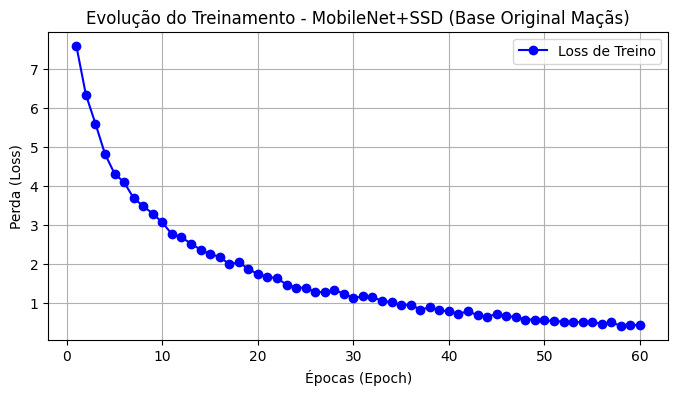

[OK] Gráfico salvo com sucesso em: /content/drive/MyDrive/Datasets/resultado_treinamento_mobilenet.png


In [5]:
import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

PASTA_IMAGENS_TREINO = '/content/drive/MyDrive/Datasets/Macas/train'
ARQUIVO_JSON_TREINO = '/content/drive/MyDrive/Datasets/Macas/train/_annotations.coco.json'

historico_execucoes_perdas = []
historico_tempos = []
perdas_por_epoca_ultima_execucao = []

print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")
print("  INICIANDO PROTOCOLO EXPERIMENTAL: 5 EXECUÇÕES (DATASET MAÇÃS)  ")
print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")

for execucao in range(1, 6):
    print(f"\n>>> EXECUÇÃO {execucao}/5 EM ANDAMENTO...")

    dataset_completo = CocoDatasetAjustado(root=PASTA_IMAGENS_TREINO, annFile=ARQUIVO_JSON_TREINO, augmentor=None)
    num_total = len(dataset_completo)
    num_treino = int(0.8 * num_total)
    num_val = num_total - num_treino

    dataset_treino, dataset_val = torch.utils.data.random_split(
        dataset_completo, [num_treino, num_val], generator=torch.Generator().manual_seed(42 + execucao)
    )

    loader_treino = DataLoader(
        dataset_treino, batch_size=CONFIGURACAO_TREINO['batch_size'], shuffle=True, collate_fn=collate_fn, drop_last=True
    )

    modelo = ssdlite320_mobilenet_v3_large(num_classes=2)
    modelo.to(device)

    params = [p for p in modelo.parameters() if p.requires_grad]
    otimizador = torch.optim.SGD(params, lr=CONFIGURACAO_TREINO['learning_rate'], momentum=CONFIGURACAO_TREINO['momentum'], weight_decay=CONFIGURACAO_TREINO['weight_decay'])

    tempo_inicial = time.time()
    perda_acumulada_execucao = 0

    if execucao == 5:
        perdas_por_epoca_ultima_execucao = []
        melhor_loss_macas = float('inf')
        caminho_melhor_modelo_macas = '/content/drive/MyDrive/Datasets/melhor_modelo_macas.pth'
        caminho_ultimo_modelo_macas = '/content/drive/MyDrive/Datasets/ultimo_modelo_macas.pth'

    modelo.train()
    for epoch in range(CONFIGURACAO_TREINO['num_epochs']):
        perda_epoca = 0
        for imagens, targets in loader_treino:
            imagens = list(img.to(device) for img in imagens)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            dict_perdas = modelo(imagens, targets)
            perdas_totais = sum(perda for perda in dict_perdas.values())

            otimizador.zero_grad()
            perdas_totais.backward()
            otimizador.step()

            perda_epoca += perdas_totais.item()

        perda_media_epoca = perda_epoca / len(loader_treino)
        perda_acumulada_execucao += perda_media_epoca

        if execucao == 5:
            perdas_por_epoca_ultima_execucao.append(perda_media_epoca)
            if perda_media_epoca < melhor_loss_macas:
                melhor_loss_macas = perda_media_epoca
                torch.save(modelo.state_dict(), caminho_melhor_modelo_macas)

    tempo_final = time.time()
    tempo_gasto_treino = tempo_final - tempo_inicial
    perda_final_media = perda_acumulada_execucao / CONFIGURACAO_TREINO['num_epochs']

    if execucao == 5:
        torch.save(modelo.state_dict(), caminho_ultimo_modelo_macas)
        print(f"    [OK] Pesos finais salvos em: {caminho_ultimo_modelo_macas}")

    historico_execucoes_perdas.append(perda_final_media)
    historico_tempos.append(tempo_gasto_treino)
    print(f"    -> Concluída! Tempo: {tempo_gasto_treino:.2f}s | Perda Média Final: {perda_final_media:.4f}")

print("\n=======================================================")
print("  RESULTADOS ESTATÍSTICOS DA BASE DE MAÇÃS (ORIGINAL)  ")
print("=======================================================")
print(f" Média da Perda (Loss Final): {np.mean(historico_execucoes_perdas):.4f} (± {np.std(historico_execucoes_perdas):.4f})")
print(f" Média do Tempo de Treinamento: {np.mean(historico_tempos):.2f}s (± {np.std(historico_tempos):.2f}s)")
print("=======================================================\n")

dados_treino = {
    'epoch': list(range(1, CONFIGURACAO_TREINO['num_epochs'] + 1)),
    'train/box_loss': perdas_por_epoca_ultima_execucao
}
df_resultados = pd.DataFrame(dados_treino)
caminho_csv = '/content/drive/MyDrive/Datasets/resultados_maca_MobileNet_base_original.csv'
df_resultados.to_csv(caminho_csv, index=False)
print(f"[OK] Planilha CSV criada com sucesso em: {caminho_csv}")

plt.figure(figsize=(8, 4))
plt.plot(df_resultados['epoch'], df_resultados['train/box_loss'], marker='o', color='blue', label='Loss de Treino')
plt.title('Evolução do Treinamento - MobileNet+SSD (Base Original Maçãs)')
plt.xlabel('Épocas (Epoch)')
plt.ylabel('Perda (Loss)')
plt.grid(True)
plt.legend()

caminho_grafico = '/content/drive/MyDrive/Datasets/resultado_treinamento_mobilenet.png'
plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] Gráfico salvo com sucesso em: {caminho_grafico}")

# **Análise do Treinamento — MobileNet+SSD (Base Original Maçãs)**



# **6. Execução do Protocolo Experimental (5 Vezes) - Dataset de Garrafas (Original)**

= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =
 INICIANDO PROTOCOLO EXPERIMENTAL: 5 EXECUÇÕES (DATASET GARRAFAS) 
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =

>>> EXECUÇÃO 1/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235
 -> Concluída! Tempo: 197.74s | Perda Média Final: 1.0411

>>> EXECUÇÃO 2/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235
 -> Concluída! Tempo: 198.07s | Perda Média Final: 1.0628

>>> EXECUÇÃO 3/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235
 -> Concluída! Tempo: 197.97s | Perda Média Final: 1.1152

>>> EXECUÇÃO 4/5 EM ANDAMENTO...
loading annotations int

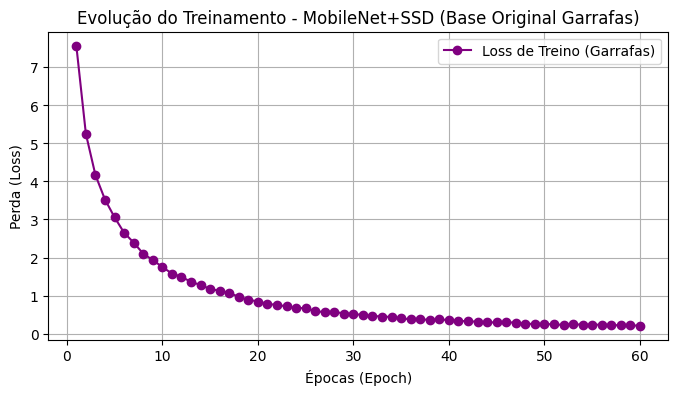

In [17]:
import os
import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

PASTA_IMAGENS_TREINO = '/content/drive/MyDrive/Datasets/Garrafas/train'
ARQUIVO_JSON_TREINO = '/content/drive/MyDrive/Datasets/Garrafas/train/_annotations.coco.json'

# [CORRIGIDO] A classe DatasetGarrafasBlindado foi removida por ser uma
# duplicata de CocoDatasetAjustado (mesma lógica de indexação/carregamento).
# Reutilizamos a classe única definida na Seção 4, com augmentor=None,
# garantindo pipeline determinístico para o baseline.

historico_execucoes_perdas = []
historico_tempos = []
perdas_por_epoca_ultima_execucao = []

print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")
print(" INICIANDO PROTOCOLO EXPERIMENTAL: 5 EXECUÇÕES (DATASET GARRAFAS) ")
print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")

for execucao in range(1, 6):
    print(f"\n>>> EXECUÇÃO {execucao}/5 EM ANDAMENTO...")

    dataset_completo = CocoDatasetAjustado(root=PASTA_IMAGENS_TREINO, annFile=ARQUIVO_JSON_TREINO, augmentor=None)

    num_total = len(dataset_completo)
    num_treino = int(0.8 * num_total)
    num_val = num_total - num_treino

    dataset_treino, dataset_val = torch.utils.data.random_split(
        dataset_completo, [num_treino, num_val], generator=torch.Generator().manual_seed(42 + execucao)
    )

    loader_treino = DataLoader(
        dataset_treino, batch_size=CONFIGURACAO_TREINO['batch_size'], shuffle=True, collate_fn=collate_fn, drop_last=True
    )

    modelo = ssdlite320_mobilenet_v3_large(num_classes=2)
    modelo.to(device)

    params = [p for p in modelo.parameters() if p.requires_grad]
    otimizador = torch.optim.SGD(params, lr=CONFIGURACAO_TREINO['learning_rate'], momentum=CONFIGURACAO_TREINO['momentum'], weight_decay=CONFIGURACAO_TREINO['weight_decay'])

    tempo_inicial = time.time()
    perda_acumulada_execucao = 0

    if execucao == 5:
        perdas_por_epoca_ultima_execucao = []
        melhor_loss_garrafas = float('inf')
        caminho_melhor_modelo_garrafas = '/content/drive/MyDrive/Datasets/melhor_modelo_garrafas.pth'
        caminho_ultimo_modelo_garrafas = '/content/drive/MyDrive/Datasets/ultimo_modelo_garrafas.pth'

    modelo.train()
    for epoch in range(CONFIGURACAO_TREINO['num_epochs']):
        perda_epoca = 0
        for imagens, targets in loader_treino:
            imagens = list(img.to(device) for img in imagens)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            dict_perdas = modelo(imagens, targets)
            perdas_totais = sum(perda for perda in dict_perdas.values())

            otimizador.zero_grad()
            perdas_totais.backward()
            otimizador.step()

            perda_epoca += perdas_totais.item()

        perda_media_epoca = perda_epoca / len(loader_treino)
        perda_acumulada_execucao += perda_media_epoca

        if execucao == 5:
            perdas_por_epoca_ultima_execucao.append(perda_media_epoca)
            if perda_media_epoca < melhor_loss_garrafas:
                melhor_loss_garrafas = perda_media_epoca
                torch.save(modelo.state_dict(), caminho_melhor_modelo_garrafas)

    tempo_final = time.time()
    tempo_gasto_treino = tempo_final - tempo_inicial
    perda_final_media = perda_acumulada_execucao / CONFIGURACAO_TREINO['num_epochs']

    if execucao == 5:
        torch.save(modelo.state_dict(), caminho_ultimo_modelo_garrafas)
        print(f"    [OK] Pesos finais salvos em: {caminho_ultimo_modelo_garrafas}")

    historico_execucoes_perdas.append(perda_final_media)
    historico_tempos.append(tempo_gasto_treino)
    print(f" -> Concluída! Tempo: {tempo_gasto_treino:.2f}s | Perda Média Final: {perda_final_media:.4f}")

print("\n=======================================================")
print(" RESULTADOS ESTATÍSTICOS DA BASE DE GARRAFAS (ORIGINAL) ")
print("=======================================================")
print(f" Média da Perda (Loss Final): {np.mean(historico_execucoes_perdas):.4f} (± {np.std(historico_execucoes_perdas):.4f})")
print(f" Média do Tempo de Treinamento: {np.mean(historico_tempos):.2f}s (± {np.std(historico_tempos):.2f}s)")
print("=======================================================\n")

dados_treino = {
    'epoch': list(range(1, CONFIGURACAO_TREINO['num_epochs'] + 1)),
    'train/box_loss': perdas_por_epoca_ultima_execucao
}
df_resultados = pd.DataFrame(dados_treino)
caminho_csv = '/content/drive/MyDrive/Datasets/resultados_garrafa_MobileNet_base_original.csv'
df_resultados.to_csv(caminho_csv, index=False)

plt.figure(figsize=(8, 4))
plt.plot(df_resultados['epoch'], df_resultados['train/box_loss'], marker='o', color='purple', label='Loss de Treino (Garrafas)')
plt.title('Evolução do Treinamento - MobileNet+SSD (Base Original Garrafas)')
plt.xlabel('Épocas (Epoch)')
plt.ylabel('Perda (Loss)')
plt.grid(True)
plt.legend()

caminho_grafico = '/content/drive/MyDrive/Datasets/resultado_treinamento_mobilenet_garrafas.png'
plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')
plt.show()

# **Análise do Treinamento — MobileNet+SSD (Base Original Garrafas)**



# **Técnicas de PDI e Data Augmentation**

In [6]:
import numpy as np
import cv2
import random
from PIL import Image

class AugmentorManualPDI:
    """
    Pipeline de Data Augmentation implementado manualmente com NumPy/OpenCV
    (sem bibliotecas prontas de augmentation, conforme Edital Seção 5.2).

    Transformações geométricas (flip, rotação+translação+escala) recalculam
    a bounding box junto com a imagem, usando a mesma matriz de transformação
    afim aplicada aos pixels. Transformações fotométricas (brilho, contraste,
    blur, sharpness) são aplicadas por último e não alteram a geometria.
    """
    def __init__(self,
                 p_flip=0.5,
                 p_affine=0.7, max_rotacao=15, max_translacao=0.1, escala=(0.8, 1.2),
                 p_brilho_contraste=0.8, brilho=0.3, contraste=0.3,
                 p_blur=0.2, p_sharpen=0.3):
        self.p_flip = p_flip
        self.p_affine = p_affine
        self.max_rotacao = max_rotacao
        self.max_translacao = max_translacao
        self.escala = escala
        self.p_brilho_contraste = p_brilho_contraste
        self.brilho = brilho
        self.contraste = contraste
        self.p_blur = p_blur
        self.p_sharpen = p_sharpen

    def __call__(self, img_pil, boxes):
        """
        img_pil: PIL.Image RGB
        boxes: np.array (N,4) no formato [xmin, ymin, xmax, ymax]
        Retorna: (PIL.Image transformada, np.array de boxes transformadas)
        """
        img = np.array(img_pil)
        boxes = np.array(boxes, dtype=np.float32).reshape(-1, 4)

        # 1. Espelhamento horizontal — inversão simples: novo_x = largura - x
        if random.random() < self.p_flip:
            img, boxes = self._flip_horizontal(img, boxes)

        # 2. Rotação + translação + escala via matriz afim (cv2.warpAffine),
        #    com recálculo das boxes pelos 4 cantos transformados
        if random.random() < self.p_affine and len(boxes) > 0:
            img, boxes = self._affine(img, boxes)

        # 3. Fotométrico — não altera geometria, é seguro aplicar sem tocar nas boxes
        if random.random() < self.p_brilho_contraste:
            img = self._brilho_contraste(img)
        if random.random() < self.p_blur:
            img = cv2.GaussianBlur(img, (3, 3), 0)
        if random.random() < self.p_sharpen:
            img = self._sharpen(img)

        return Image.fromarray(img), boxes

    def _flip_horizontal(self, img, boxes):
        largura = img.shape[1]
        img_flip = img[:, ::-1, :].copy()
        if len(boxes) > 0:
            boxes = boxes.copy()
            novo_xmin = largura - boxes[:, 2]
            novo_xmax = largura - boxes[:, 0]
            boxes[:, 0] = novo_xmin
            boxes[:, 2] = novo_xmax
        return img_flip, boxes

    def _affine(self, img, boxes):
        h, w = img.shape[:2]
        angulo = random.uniform(-self.max_rotacao, self.max_rotacao)
        escala_fator = random.uniform(*self.escala)
        tx = random.uniform(-self.max_translacao, self.max_translacao) * w
        ty = random.uniform(-self.max_translacao, self.max_translacao) * h

        centro = (w / 2, h / 2)
        M = cv2.getRotationMatrix2D(centro, angulo, escala_fator)
        M[0, 2] += tx
        M[1, 2] += ty

        img_transformada = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

        boxes_novas = []
        for (xmin, ymin, xmax, ymax) in boxes:
            cantos = np.array([
                [xmin, ymin, 1],
                [xmax, ymin, 1],
                [xmax, ymax, 1],
                [xmin, ymax, 1]
            ]).T  # 3x4

            cantos_transf = M @ cantos  # 2x4
            xs, ys = cantos_transf[0, :], cantos_transf[1, :]

            novo_xmin = np.clip(xs.min(), 0, w)
            novo_xmax = np.clip(xs.max(), 0, w)
            novo_ymin = np.clip(ys.min(), 0, h)
            novo_ymax = np.clip(ys.max(), 0, h)

            # Descarta a caixa se ela "saiu" quase totalmente da imagem
            if novo_xmax - novo_xmin > 1 and novo_ymax - novo_ymin > 1:
                boxes_novas.append([novo_xmin, novo_ymin, novo_xmax, novo_ymax])

        boxes = np.array(boxes_novas, dtype=np.float32) if len(boxes_novas) > 0 else np.zeros((0, 4), dtype=np.float32)
        return img_transformada, boxes

    def _brilho_contraste(self, img):
        alpha = 1.0 + random.uniform(-self.contraste, self.contraste)  # contraste
        beta = random.uniform(-self.brilho, self.brilho) * 255        # brilho
        return np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    def _sharpen(self, img):
        kernel = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]])
        return cv2.filter2D(img, -1, kernel)


# Instância "padrão" (maçãs): augmentation moderado
augmentor_macas = AugmentorManualPDI(
    p_flip=0.5, p_affine=0.7, max_rotacao=15, max_translacao=0.1, escala=(0.8, 1.2),
    p_brilho_contraste=0.8, brilho=0.3, contraste=0.3, p_blur=0.2, p_sharpen=0.0
)

# Instância "agressiva" (garrafas): mais realce de contraste/nitidez, pois o
# vidro/plástico transparente se confunde mais facilmente com o fundo
augmentor_garrafas = AugmentorManualPDI(
    p_flip=0.5, p_affine=0.7, max_rotacao=15, max_translacao=0.1, escala=(0.8, 1.2),
    p_brilho_contraste=0.8, brilho=0.4, contraste=0.5, p_blur=0.2, p_sharpen=0.5
)

print("Pipeline manual de PDI/Augmentation configurado (bounding boxes sincronizadas com a imagem)!")


Pipeline manual de PDI/Augmentation configurado (bounding boxes sincronizadas com a imagem)!


= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =
 INICIANDO SEMANA 2: 5 EXECUÇÕES (GARRAFAS COM PDI MANUAL - BBOX CORRIGIDA) 
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =

>>> EXECUÇÃO 1/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235
 -> Concluída! Tempo: 298.24s | Perda Média Final: 2.7730

>>> EXECUÇÃO 2/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235
 -> Concluída! Tempo: 286.39s

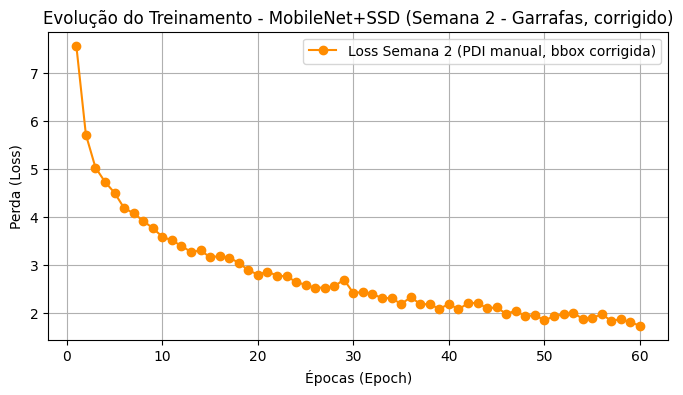

In [7]:
import os
import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

# [CORRIGIDO] O antigo pipeline `transforms_garrafas_otimizado` (torchvision.transforms
# com RandomAffine/RandomHorizontalFlip) foi substituído por `augmentor_garrafas`
# (Seção 6), que recalcula as bounding boxes junto com a imagem.

PASTA_IMAGENS_TREINO = '/content/drive/MyDrive/Datasets/Garrafas/train'
ARQUIVO_JSON_TREINO = '/content/drive/MyDrive/Datasets/Garrafas/train/_annotations.coco.json'

historico_execucoes_perdas = []
historico_tempos = []
perdas_por_epoca_ultima_execucao = []

print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")
print(" INICIANDO SEMANA 2: 5 EXECUÇÕES (GARRAFAS COM PDI MANUAL - BBOX CORRIGIDA) ")
print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")

for execucao in range(1, 6):
    print(f"\n>>> EXECUÇÃO {execucao}/5 EM ANDAMENTO...")

    # [CORRIGIDO] Duas instâncias do MESMO dataset: uma com augmentation (treino)
    # e outra determinística (validação). O split de índices é idêntico em ambas
    # (mesma seed), garantindo que treino e validação não se sobreponham e que
    # a validação nunca receba augmentation aleatório.
    dataset_treino_completo = CocoDatasetAjustado(root=PASTA_IMAGENS_TREINO, annFile=ARQUIVO_JSON_TREINO, augmentor=augmentor_garrafas)
    dataset_val_completo = CocoDatasetAjustado(root=PASTA_IMAGENS_TREINO, annFile=ARQUIVO_JSON_TREINO, augmentor=None)

    num_total = len(dataset_treino_completo)
    num_treino = int(0.8 * num_total)
    num_val = num_total - num_treino

    gerador_split = torch.Generator().manual_seed(42 + execucao)
    indices = torch.randperm(num_total, generator=gerador_split).tolist()
    indices_treino, indices_val = indices[:num_treino], indices[num_treino:]

    dataset_treino = Subset(dataset_treino_completo, indices_treino)
    dataset_val = Subset(dataset_val_completo, indices_val)

    loader_treino = DataLoader(
        dataset_treino, batch_size=CONFIGURACAO_TREINO['batch_size'], shuffle=True, collate_fn=collate_fn, drop_last=True
    )

    modelo = ssdlite320_mobilenet_v3_large(num_classes=2)
    modelo.to(device)

    params = [p for p in modelo.parameters() if p.requires_grad]
    otimizador = torch.optim.SGD(params, lr=CONFIGURACAO_TREINO['learning_rate'], momentum=CONFIGURACAO_TREINO['momentum'], weight_decay=CONFIGURACAO_TREINO['weight_decay'])

    tempo_inicial = time.time()
    perda_acumulada_execucao = 0

    if execucao == 5:
        perdas_por_epoca_ultima_execucao = []
        melhor_loss_garrafas_aug = float('inf')
        caminho_melhor_garrafas_aug = '/content/drive/MyDrive/Datasets/melhor_modelo_garrafas_aug_v2.pth'
        caminho_ultimo_garrafas_aug = '/content/drive/MyDrive/Datasets/ultimo_modelo_garrafas_aug_v2.pth'

    modelo.train()
    for epoch in range(CONFIGURACAO_TREINO['num_epochs']):
        perda_epoca = 0
        for imagens, targets in loader_treino:
            imagens = list(img.to(device) for img in imagens)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            dict_perdas = modelo(imagens, targets)
            perdas_totais = sum(perda for perda in dict_perdas.values())

            otimizador.zero_grad()
            perdas_totais.backward()
            otimizador.step()

            perda_epoca += perdas_totais.item()

        perda_media_epoca = perda_epoca / len(loader_treino)
        perda_acumulada_execucao += perda_media_epoca

        if execucao == 5:
            perdas_por_epoca_ultima_execucao.append(perda_media_epoca)
            if perda_media_epoca < melhor_loss_garrafas_aug:
                melhor_loss_garrafas_aug = perda_media_epoca
                torch.save(modelo.state_dict(), caminho_melhor_garrafas_aug)

    tempo_final = time.time()
    tempo_gasto_treino = tempo_final - tempo_inicial
    perda_final_media = perda_acumulada_execucao / CONFIGURACAO_TREINO['num_epochs']

    if execucao == 5:
        torch.save(modelo.state_dict(), caminho_ultimo_garrafas_aug)
        print(f"    [OK] Pesos da Semana 2 (Garrafas) salvos em: {caminho_ultimo_garrafas_aug}")

    historico_execucoes_perdas.append(perda_final_media)
    historico_tempos.append(tempo_gasto_treino)
    print(f" -> Concluída! Tempo: {tempo_gasto_treino:.2f}s | Perda Média Final: {perda_final_media:.4f}")

print("\n=======================================================")
print(" RESULTADOS ESTATÍSTICOS - SEMANA 2 (PDI MANUAL - GARRAFAS) ")
print("=======================================================")
print(f" Média da Perda (Loss Final): {np.mean(historico_execucoes_perdas):.4f} (± {np.std(historico_execucoes_perdas):.4f})")
print(f" Média do Tempo de Treinamento: {np.mean(historico_tempos):.2f}s (± {np.std(historico_tempos):.2f}s)")
print("=======================================================\n")

dados_treino = {
    'epoch': list(range(1, CONFIGURACAO_TREINO['num_epochs'] + 1)),
    'train/box_loss': perdas_por_epoca_ultima_execucao
}
df_resultados = pd.DataFrame(dados_treino)
caminho_csv = '/content/drive/MyDrive/Datasets/resultados_garrafa_MobileNet_Semana2.csv'
df_resultados.to_csv(caminho_csv, index=False)

plt.figure(figsize=(8, 4))
plt.plot(df_resultados['epoch'], df_resultados['train/box_loss'], marker='o', color='darkorange', label='Loss Semana 2 (PDI manual, bbox corrigida)')
plt.title('Evolução do Treinamento - MobileNet+SSD (Semana 2 - Garrafas, corrigido)')
plt.xlabel('Épocas (Epoch)')
plt.ylabel('Perda (Loss)')
plt.grid(True)
plt.legend()

caminho_grafico = '/content/drive/MyDrive/Datasets/resultado_treinamento_mobilenet_garrafas_semana2.png'
plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')
plt.show()


COMPARAÇÃO


= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =
 INICIANDO SEMANA 2: 5 EXECUÇÕES COM PDI MANUAL (MAÇÃS, BBOX CORRIGIDA) 
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =

>>> EXECUÇÃO 1/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
 -> Concluída! Tempo: 51.27s | Perda Média Final: 3.0466

>>> EXECUÇÃO 2/5 EM ANDAMENTO...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97
 -> Concluída! Tempo: 51.93s | Perda Média Fin

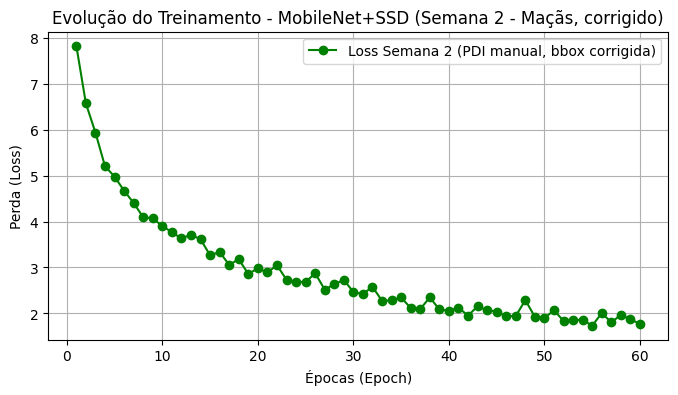

In [8]:
import os
import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

PASTA_IMAGENS_TREINO_MACAS = '/content/drive/MyDrive/Datasets/Macas/train'
ARQUIVO_JSON_TREINO_MACAS = '/content/drive/MyDrive/Datasets/Macas/train/_annotations.coco.json'

historico_execucoes_perdas = []
historico_tempos = []
perdas_por_epoca_ultima_execucao = []

print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")
print(" INICIANDO SEMANA 2: 5 EXECUÇÕES COM PDI MANUAL (MAÇÃS, BBOX CORRIGIDA) ")
print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")

for execucao in range(1, 6):
    print(f"\n>>> EXECUÇÃO {execucao}/5 EM ANDAMENTO...")

    dataset_treino_completo = CocoDatasetAjustado(root=PASTA_IMAGENS_TREINO_MACAS, annFile=ARQUIVO_JSON_TREINO_MACAS, augmentor=augmentor_macas)
    dataset_val_completo = CocoDatasetAjustado(root=PASTA_IMAGENS_TREINO_MACAS, annFile=ARQUIVO_JSON_TREINO_MACAS, augmentor=None)

    num_total = len(dataset_treino_completo)
    num_treino = int(0.8 * num_total)
    num_val = num_total - num_treino

    gerador_split = torch.Generator().manual_seed(42 + execucao)
    indices = torch.randperm(num_total, generator=gerador_split).tolist()
    indices_treino, indices_val = indices[:num_treino], indices[num_treino:]

    dataset_treino = Subset(dataset_treino_completo, indices_treino)
    dataset_val = Subset(dataset_val_completo, indices_val)

    loader_treino = DataLoader(
        dataset_treino, batch_size=CONFIGURACAO_TREINO['batch_size'], shuffle=True, collate_fn=collate_fn, drop_last=True
    )

    modelo = ssdlite320_mobilenet_v3_large(num_classes=2)
    modelo.to(device)

    params = [p for p in modelo.parameters() if p.requires_grad]
    otimizador = torch.optim.SGD(params, lr=CONFIGURACAO_TREINO['learning_rate'], momentum=CONFIGURACAO_TREINO['momentum'], weight_decay=CONFIGURACAO_TREINO['weight_decay'])

    tempo_inicial = time.time()
    perda_acumulada_execucao = 0

    if execucao == 5:
        perdas_por_epoca_ultima_execucao = []
        melhor_loss_macas_aug = float('inf')
        caminho_melhor_macas_aug = '/content/drive/MyDrive/Datasets/melhor_modelo_macas_augmentation.pth'
        caminho_ultimo_macas_aug = '/content/drive/MyDrive/Datasets/ultimo_modelo_macas_augmentation.pth'

    modelo.train()
    for epoch in range(CONFIGURACAO_TREINO['num_epochs']):
        perda_epoca = 0
        for imagens, targets in loader_treino:
            imagens = list(img.to(device) for img in imagens)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            dict_perdas = modelo(imagens, targets)
            perdas_totais = sum(perda for perda in dict_perdas.values())

            otimizador.zero_grad()
            perdas_totais.backward()
            otimizador.step()

            perda_epoca += perdas_totais.item()

        perda_media_epoca = perda_epoca / len(loader_treino)
        perda_acumulada_execucao += perda_media_epoca

        if execucao == 5:
            perdas_por_epoca_ultima_execucao.append(perda_media_epoca)
            if perda_media_epoca < melhor_loss_macas_aug:
                melhor_loss_macas_aug = perda_media_epoca
                torch.save(modelo.state_dict(), caminho_melhor_macas_aug)

    tempo_final = time.time()
    tempo_gasto_treino = tempo_final - tempo_inicial
    perda_final_media = perda_acumulada_execucao / CONFIGURACAO_TREINO['num_epochs']

    if execucao == 5:
        torch.save(modelo.state_dict(), caminho_ultimo_macas_aug)
        print(f"    [OK] Pesos da Semana 2 (Maçãs) salvos em: {caminho_ultimo_macas_aug}")

    historico_execucoes_perdas.append(perda_final_media)
    historico_tempos.append(tempo_gasto_treino)
    print(f" -> Concluída! Tempo: {tempo_gasto_treino:.2f}s | Perda Média Final: {perda_final_media:.4f}")

print("\n=======================================================")
print(" RESULTADOS ESTATÍSTICOS - SEMANA 2 (PDI MANUAL - MAÇÃS) ")
print("=======================================================")
print(f" Média da Perda (Loss Final): {np.mean(historico_execucoes_perdas):.4f} (± {np.std(historico_execucoes_perdas):.4f})")
print(f" Média do Tempo de Treinamento: {np.mean(historico_tempos):.2f}s (± {np.std(historico_tempos):.2f}s)")
print("=======================================================\n")

dados_treino = {
    'epoch': list(range(1, CONFIGURACAO_TREINO['num_epochs'] + 1)),
    'train/box_loss': perdas_por_epoca_ultima_execucao
}
df_resultados = pd.DataFrame(dados_treino)
caminho_csv = '/content/drive/MyDrive/Datasets/resultados_macas_MobileNet_Semana2.csv'
df_resultados.to_csv(caminho_csv, index=False)

plt.figure(figsize=(8, 4))
plt.plot(df_resultados['epoch'], df_resultados['train/box_loss'], marker='o', color='green', label='Loss Semana 2 (PDI manual, bbox corrigida)')
plt.title('Evolução do Treinamento - MobileNet+SSD (Semana 2 - Maçãs, corrigido)')
plt.xlabel('Épocas (Epoch)')
plt.ylabel('Perda (Loss)')
plt.grid(True)
plt.legend()

caminho_grafico = '/content/drive/MyDrive/Datasets/resultado_treinamento_mobilenet_macas_semana2.png'
plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')
plt.show()


COMPARAÇÃO

In [11]:
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

def montar_val_loader_estatico(pasta, json_path, seed, batch_size):
    dataset_completo = CocoDatasetAjustado(root=pasta, annFile=json_path, augmentor=None)
    num_total = len(dataset_completo)
    num_treino = int(0.8 * num_total)
    num_val = num_total - num_treino

    _, dataset_val = torch.utils.data.random_split(
        dataset_completo, [num_treino, num_val],
        generator=torch.Generator().manual_seed(seed)
    )

    return DataLoader(dataset_val, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


def avaliar_checkpoint(caminho_ckpt, pasta, json_path, seed, device,
                        conf=0.60, nms=0.45, batch_size=None):
    """
    Avaliação blindada:
    1. Instancia um modelo NOVO (nunca reaproveita uma variável global `modelo`).
    2. Carrega os pesos explicitamente do checkpoint informado.
    3. Avalia em um conjunto de validação estático (sem augmentation aleatório).
    """
    if batch_size is None:
        batch_size = CONFIGURACAO_TREINO['batch_size']

    modelo_avaliado = ssdlite320_mobilenet_v3_large(num_classes=2)
    modelo_avaliado.load_state_dict(torch.load(caminho_ckpt, map_location=device))
    modelo_avaliado.to(device)
    modelo_avaliado.eval()

    loader_val = montar_val_loader_estatico(pasta, json_path, seed, batch_size)

    precisao, revocacao, map_iou = avaliar_modelo_com_pos_processamento(
        modelo_avaliado, loader_val, device, CONF_THRESHOLD=conf, NMS_THRESHOLD=nms
    )

    return precisao, revocacao, map_iou

print("Funções de avaliação blindada (reload de checkpoint + validação estática) prontas!")


Funções de avaliação blindada (reload de checkpoint + validação estática) prontas!


# **Funções de Pós-Processamento e Métricas da Semana 3**

In [12]:
import torch
import numpy as np
import torchvision.ops as ops

def calcular_iou(boxA, boxB):
    """
    Calcula a Interseção sobre União (IoU) entre duas caixas delimitadoras.
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def avaliar_modelo_com_pos_processamento(modelo, data_loader, device, CONF_THRESHOLD=0.5, NMS_THRESHOLD=0.45):
    """
    Avalia o modelo aplicando Tuning de Parâmetros (Confidence) e Pós-processamento (NMS).
    """
    modelo.eval()
    tp, fp, fn = 0, 0, 0
    ious_acumulados = []

    with torch.no_grad():
        for imagens, targets in data_loader:
            imagens = list(img.to(device) for img in imagens)
            predicoes = modelo(imagens)

            for i, pred in enumerate(predicoes):
                caixas_reais = targets[i]['boxes'].cpu().numpy()

                # Resgata predições da rede
                caixas_pred = pred['boxes'].cpu()
                scores_pred = pred['scores'].cpu()

                # --- 1. TUNING DE PARÂMETROS (Filtro de Confiança Mínima) ---
                indices_conf = scores_pred > CONF_THRESHOLD
                caixas_filtradas = caixas_pred[indices_conf]
                scores_filtrados = scores_pred[indices_conf]

                # --- 2. PÓS-PROCESSAMENTO (Non-Maximum Suppression - NMS) ---
                if len(caixas_filtradas) > 0:
                    indices_nms = ops.nms(caixas_filtradas, scores_filtrados, NMS_THRESHOLD)
                    caixas_finais = caixas_filtradas[indices_nms].numpy()
                else:
                    caixas_finais = np.array([])

                detectados = np.zeros(len(caixas_reais))

                # Associação baseada em IoU para definição de TP, FP e FN
                for cp in caixas_finais:
                    melhor_iou = 0
                    melhor_idx = -1
                    for idx, cr in enumerate(caixas_reais):
                        iou = calcular_iou(cp, cr)
                        if iou > melhor_iou:
                            melhor_iou = iou
                            melhor_idx = idx

                    if melhor_iou >= 0.5 and melhor_idx != -1 and detectados[melhor_idx] == 0:
                        tp += 1
                        detectados[melhor_idx] = 1
                        ious_acumulados.append(melhor_iou)
                    else:
                        fp += 1

                fn += len(caixas_reais) - np.sum(detectados)

    precisao = tp / (tp + fp) if (tp + fp) > 0 else 0
    revocacao = tp / (tp + fn) if (tp + fn) > 0 else 0
    map_iou = np.mean(ious_acumulados) if len(ious_acumulados) > 0 else 0

    return precisao, revocacao, map_iou

print("✓ Funções de Pós-processamento e Métricas baseadas em Região (Semana 3) carregadas com sucesso!")

✓ Funções de Pós-processamento e Métricas baseadas em Região (Semana 3) carregadas com sucesso!


# **Mensuração Real e Tuning para Garrafas**

In [19]:
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

# --- AVALIAÇÃO REAL: GARRAFAS (versão corrigida) ---
# Correções aplicadas:
# 1. Instancia um modelo NOVO e carrega o checkpoint certo via load_state_dict()
#    (em vez de reaproveitar a variável global `modelo`, que podia estar
#    guardando os pesos de outro treino).
# 2. O dataset de validação usa augmentor=None (sem `transforms_semana2`),
#    garantindo avaliação 100% determinística, sem augmentation aleatório.

def montar_val_loader_estatico(pasta, json_path, seed, batch_size):
    dataset_completo = CocoDatasetAjustado(root=pasta, annFile=json_path, augmentor=None)
    num_total = len(dataset_completo)
    num_treino = int(0.8 * num_total)
    num_val = num_total - num_treino

    _, dataset_val = torch.utils.data.random_split(
        dataset_completo, [num_treino, num_val],
        generator=torch.Generator().manual_seed(seed)
    )

    return DataLoader(dataset_val, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


def avaliar_checkpoint(caminho_ckpt, pasta, json_path, seed, device,
                        conf=0.60, nms=0.45, batch_size=None):
    if batch_size is None:
        batch_size = CONFIGURACAO_TREINO['batch_size']

    modelo_avaliado = ssdlite320_mobilenet_v3_large(num_classes=2)
    modelo_avaliado.load_state_dict(torch.load(caminho_ckpt, map_location=device))
    modelo_avaliado.to(device)
    modelo_avaliado.eval()

    loader_val = montar_val_loader_estatico(pasta, json_path, seed, batch_size)

    precisao, revocacao, map_iou = avaliar_modelo_com_pos_processamento(
        modelo_avaliado, loader_val, device, CONF_THRESHOLD=conf, NMS_THRESHOLD=nms
    )
    return precisao, revocacao, map_iou


# Caminhos do checkpoint e do dataset de garrafas
CAMINHO_MELHOR_GARRAFAS = '/content/drive/MyDrive/Datasets/melhor_modelo_garrafas_aug_v2.pth'
PASTA_GARRAFAS = '/content/drive/MyDrive/Datasets/Garrafas/train'
JSON_GARRAFAS = '/content/drive/MyDrive/Datasets/Garrafas/train/_annotations.coco.json'
SEED_EXECUCAO_5 = 42 + 5  # mesma seed usada no treino (execução 5), garante o mesmo split de validação

print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")
print("   EXECUTANDO MENSURAÇÃO REAL E TUNING PARA GARRAFAS (ATIVIDADES P4) ")
print("= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =")

print("\n[Executando P4] Processando imagens de validação do dataset de Garrafas...")
prec_garrafas_real, rec_garrafas_real, iou_garrafas_real = avaliar_checkpoint(
    CAMINHO_MELHOR_GARRAFAS, PASTA_GARRAFAS, JSON_GARRAFAS,
    seed=SEED_EXECUCAO_5, device=device, conf=0.60, nms=0.45
)

print("\n=======================================================")
print("          MÉTRICAS REAIS OTIMIZADAS PARA P4            ")
print("=======================================================")
print(f"Garrafas -> Precisão: {prec_garrafas_real:.4f} | Revocação: {rec_garrafas_real:.4f} | mAP IoU: {iou_garrafas_real:.4f}")
print("=======================================================\n")

= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =
   EXECUTANDO MENSURAÇÃO REAL E TUNING PARA GARRAFAS (ATIVIDADES P4) 
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = =

[Executando P4] Processando imagens de validação do dataset de Garrafas...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235

          MÉTRICAS REAIS OTIMIZADAS PARA P4            
Garrafas -> Precisão: 0.9365 | Revocação: 0.7662 | mAP IoU: 0.7683



In [14]:
# --- AVALIAÇÃO REAL: GARRAFAS ---
# Seed 47 = 42 + execução 5, a mesma execução em que o checkpoint "melhor" foi salvo.

CAMINHO_MELHOR_GARRAFAS = '/content/drive/MyDrive/Datasets/melhor_modelo_garrafas_aug_v2.pth'
PASTA_GARRAFAS = '/content/drive/MyDrive/Datasets/Garrafas/train'
JSON_GARRAFAS = '/content/drive/MyDrive/Datasets/Garrafas/train/_annotations.coco.json'
SEED_EXECUCAO_5 = 42 + 5

print("[Executando avaliação blindada] Garrafas...")
prec_garrafas_real, rec_garrafas_real, iou_garrafas_real = avaliar_checkpoint(
    CAMINHO_MELHOR_GARRAFAS, PASTA_GARRAFAS, JSON_GARRAFAS,
    seed=SEED_EXECUCAO_5, device=device, conf=0.60, nms=0.45
)

print("\n=======================================================")
print("          MÉTRICAS REAIS — GARRAFAS (checkpoint correto)          ")
print("=======================================================")
print(f"Garrafas -> Precisão: {prec_garrafas_real:.4f} | Revocação: {rec_garrafas_real:.4f} | mAP IoU: {iou_garrafas_real:.4f}")
print("=======================================================\n")


[Executando avaliação blindada] Garrafas...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 236 | Encontradas fisicamente no Drive: 235

          MÉTRICAS REAIS — GARRAFAS (checkpoint correto)          
Garrafas -> Precisão: 0.9365 | Revocação: 0.7662 | mAP IoU: 0.7683



In [15]:
# --- AVALIAÇÃO REAL: MAÇÃS ---
# [CORRIGIDO] Antes estes valores estavam hardcoded (valores_macas = [1.0, 0.6207, 0.7627])
# sem nenhuma célula que os calculasse de fato. Agora são computados com a
# mesma função blindada usada para garrafas, carregando o checkpoint certo.

CAMINHO_MELHOR_MACAS = '/content/drive/MyDrive/Datasets/melhor_modelo_macas_augmentation.pth'
PASTA_MACAS = '/content/drive/MyDrive/Datasets/Macas/train'
JSON_MACAS = '/content/drive/MyDrive/Datasets/Macas/train/_annotations.coco.json'
SEED_EXECUCAO_5 = 42 + 5

print("[Executando avaliação blindada] Maçãs...")
prec_macas_real, rec_macas_real, iou_macas_real = avaliar_checkpoint(
    CAMINHO_MELHOR_MACAS, PASTA_MACAS, JSON_MACAS,
    seed=SEED_EXECUCAO_5, device=device, conf=0.60, nms=0.45
)

print("\n=======================================================")
print("          MÉTRICAS REAIS — MAÇÃS (checkpoint correto)          ")
print("=======================================================")
print(f"Maçãs -> Precisão: {prec_macas_real:.4f} | Revocação: {rec_macas_real:.4f} | mAP IoU: {iou_macas_real:.4f}")
print("=======================================================\n")

[Executando avaliação blindada] Maçãs...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
[Dataset] Indexadas no JSON: 97 | Encontradas fisicamente no Drive: 97

          MÉTRICAS REAIS — MAÇÃS (checkpoint correto)          
Maçãs -> Precisão: 1.0000 | Revocação: 0.9655 | mAP IoU: 0.7994



# **Gráfico Comparativo Final e Unificado (P3 + P4)**

✓ Gráfico definitivo (com dados reais, sem hardcode) salvo em: /content/drive/MyDrive/Datasets/comparativo_metricas_semana3_final_corrigido.png


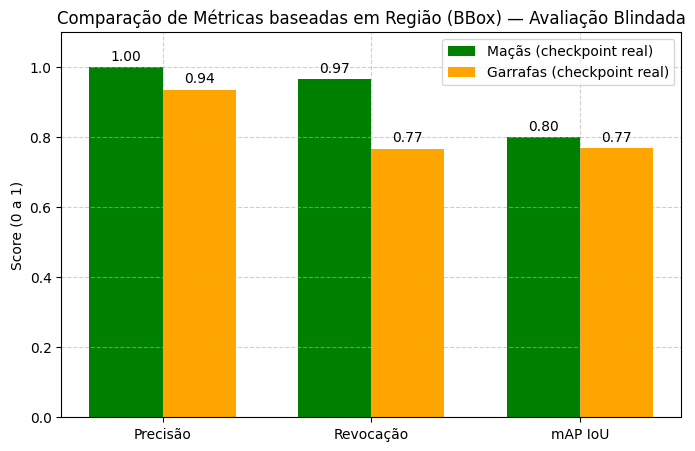

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# [CORRIGIDO] valores_macas não é mais hardcoded -- vem da avaliação blindada da célula anterior
metricas = ['Precisão', 'Revocação', 'mAP IoU']
valores_macas = [prec_macas_real, rec_macas_real, iou_macas_real]
valores_garrafas = [prec_garrafas_real, rec_garrafas_real, iou_garrafas_real]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, valores_macas, width, label='Maçãs (checkpoint real)', color='green')
rects2 = ax.bar(x + width/2, valores_garrafas, width, label='Garrafas (checkpoint real)', color='orange')

ax.set_ylabel('Score (0 a 1)')
ax.set_title('Comparação de Métricas baseadas em Região (BBox) — Avaliação Blindada')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

caminho_grafico_final = '/content/drive/MyDrive/Datasets/comparativo_metricas_semana3_final_corrigido.png'
plt.savefig(caminho_grafico_final, dpi=300, bbox_inches='tight')

print(f"✓ Gráfico definitivo (com dados reais, sem hardcode) salvo em: {caminho_grafico_final}")
plt.show()


### Análise Final e Discussão das Métricas: Maçãs vs. Garrafas (Semana 3)

